# MULTIMODAL training

## Notebok for training the models. They are saved and later loaded in another notebook for tests.

### Multimodal experiments:


1.   Clinical close-up images + full metadata: (skin type, age_approximate, lession location, sex)
2.   Clinical close-up images + reduced metadata: (age_approximate, skin type)
3.   Clinical close-up images + dermoscopic images
4.   Clinical close-up images + dermoscopic images + full metadata: (skin type, age_approximate, lession location, sex)

### Architectures:
1. For first set of modalities:


*   Learned feature fusion using Multiplication
*   Learned feature fusion using Concatenation
*   CrossAttention


2. For second set of modalities:


*   Learned feature fusion using Multiplication
*   Learned feature fusion using Concatenation
*   CrossAttention

3. For third set of modalities:

*   Mutual cross attention using clinical image as query and dermoscopic as key and values and dermoscopic image as query and clinical image as key and value

4. For forth set of modalities:

*   Mutual cross attention


### Training approach:

Two stage training: 1st is by freezing the backbone layers and training the custom networks (in learned feature fusion) and custom classification heads of ViT, and the 2nd by unfreezing all layers and retraining. Each stage is saved in a file with the suffix: _stage_<stage>

The learning rate for training the head and the full model is different. It is:

best_lr_head = 0.0004615619914925977

best_lr_full = 1.1526026851977796e-05

These are the learning rates which performed the best for the ViT model with a custom head, used as a building block in all of the models. After performing first test of model architectures, I decided that the final comnbination of multiple modalities gives best results.

Parameter search via Optuna is used only for the final modalities combination: image + image + full metadata.

Early stopping with patience 10 is used for both stages, based on the validation loss, so that more stable results are prioritized. 1000 original epochs count is never reached.









In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

WORK_DIR_ROOT = '/content/drive/MyDrive/datasets/Master/'
sys.path.append(WORK_DIR_ROOT)

from utils import *


DATASET_ROOT = '/content/drive/MyDrive/datasets/Master/datasets_orig'
METADATA_TRAIN_PATH = f"{DATASET_ROOT}/MILK10k_Training_Metadata.csv"
METADATA_TEST_PATH = f"{DATASET_ROOT}/MILK10k_Test_Metadata.csv"
DATASET_TRAIN = f"{DATASET_ROOT}/MILK10k_Training_Input/MILK10k_Training_Input/"
DATASET_RESIZED = f"{WORK_DIR_ROOT}/datasets_resized_stratified/"
GT_PATH = f"{DATASET_ROOT}/MILK10k_Training_GroundTruth.csv"


CHECKPOINT_DIR = WORK_DIR_ROOT + 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Mounted at /content/drive


# 1. Clinical close-up images + full metadata: (skin type, age_approximate, lession location, sex)

## Load data

### Load data and metadata

In [2]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "sex", "skin_tone_class", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

df_train_clinical_minimal.head()

,lesion_id,isic_id,image_type,age_approx,sex,skin_tone_class,site,label_id
0,IL_0000652,ISIC_8149219,clinical: close-up,70.0,male,1,head_neck_face,1
1,IL_0003176,ISIC_3904045,clinical: close-up,45.0,female,5,head_neck_face,1
2,IL_0004688,ISIC_0791494,clinical: close-up,50.0,male,3,lower_extremity,1
3,IL_0005081,ISIC_5667730,clinical: close-up,45.0,male,3,head_neck_face,9
4,IL_0006177,ISIC_8803389,clinical: close-up,75.0,male,3,upper_extremity,1


### Prepare map for metadata one-hot encoding so that each value and metadata column have the same order:

In [3]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

if False: # I have already created it and saved it, so shouldn't do it again.
  metadata_maps = build_metadata_maps(df_train_clinical_minimal, metadata_cols)

  # save the metadata maps:
  with open(WORK_DIR_ROOT + "/metadata_maps.json", "w") as f:
    json.dump(metadata_maps, f, indent=2)

# load the maps, because almost certainly I'll have to rerun the whole colab:
with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


### Load the lession_ids for train/val/test stratified datasets

In [4]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# Train
df_train_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(train_lesions)
].reset_index(drop=True)

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)



Lesions - Train: 4191, Val: 524, Test: 525


### Create data loaders with a custom dataset class

For this purpose, use a custom Dataset called Milk10kDataset_multimodal, which receives a dataframe to read the metadata and labels from, a root directory to read the image files from, a custom transform to apply to the images. It assumes only one image type, so we filter beforehand.



### Create the data transformers

In [5]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()])

validation_transform = transforms.Compose([
    transforms.ToTensor()])

### Create the data loaders

In [6]:
from utils import Milk10kDataset_multimodal
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_dataset = Milk10kDataset_multimodal(
    df_train_clinical,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,   # None means automatically take all non-image/non-label columns
    transform=train_transform,
    smoothing=0.1
)

val_dataset = Milk10kDataset_multimodal(
    df_val_clinical,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform,
    smoothing=0.1
)

NUM_WORKERS = os.cpu_count()

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

train_loader, val_loader

Using device: cuda


(<torch.utils.data.dataloader.DataLoader at 0x7bcaf62067e0>,
 <torch.utils.data.dataloader.DataLoader at 0x7bcaf63343e0>)

In [7]:
img, meta, label = next(iter(train_loader))

# Note that batch size will now be 1.
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")
print(f"Meta shape: {meta.shape}")

Image shape: torch.Size([32, 3, 224, 224]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])
Meta shape: torch.Size([32, 34])


In [8]:
print("Meta shape:", meta.shape)
print("First 3 metadata vectors:\n", meta[:3])

Meta shape: torch.Size([32, 34])
First 3 metadata vectors:
 tensor([[0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500,
         0.0500, 0.0500, 0.9000, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500,
         0.0500, 0.9000, 0.0500, 0.0500, 0.0500, 0.9000, 0.0500, 0.0500, 0.0500,
         0.0500, 0.0500, 0.0500, 0.0500, 0.9000, 0.0500, 0.0500],
        [0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.9000, 0.0500, 0.0500, 0.0500,
         0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500,
         0.0500, 0.9000, 0.0500, 0.0500, 0.0500, 0.0500, 0.9000, 0.0500, 0.0500,
         0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.9000, 0.0500],
        [0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500,
         0.0500, 0.0500, 0.0500, 0.9000, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500,
         0.0500, 0.9000, 0.0500, 0.0500, 0.0500, 0.9000, 0.0500, 0.0500, 0.0500,
         0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.9000, 0.0500]])


In [9]:
unique_ages = df_train_clinical['age_approx'].unique()
print("Unique ages:", unique_ages)

unique_sites = df_train_clinical['site'].unique()
print("Unique site:", unique_sites)

#unique sex:
unique_sex = df_train_clinical['sex'].unique()
print("Unique sex:", unique_sex)

#unique skin tone:
unique_skin_tone = df_train_clinical['skin_tone_class'].unique()
print("Unique skin tone:", unique_skin_tone)

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")



Unique ages: [45. 50. 75. 70. 60. 30. 65. 40. 55. 35.  5. 80. 85. 20. 25. 10. 15. nan]
Unique site: ['head_neck_face' 'lower_extremity' 'upper_extremity' 'trunk' nan 'foot'
 'genital' 'hand']
Unique sex: ['female' 'male']
Unique skin tone: [5 3 2 4 1 0]
metadata input dimension: 34


best_lr_head = 0.0004615619914925977
  best_lr_full = 1.1526026851977796e-05

## Train models

## 1.1 Learned feature fusion usin multiplication
Clinical close-up image + full metadata (skin, sex, age, site)

metadata input dimension: 34
Epoch [1/1000] | Train Loss: 1.4768 | Val Loss: 1.1813 | Val Acc: 0.5916
Best model + history saved
Epoch [2/1000] | Train Loss: 1.2346 | Val Loss: 1.1267 | Val Acc: 0.6145
Best model + history saved
Epoch [3/1000] | Train Loss: 1.1677 | Val Loss: 1.1162 | Val Acc: 0.6183
Best model + history saved
Epoch [4/1000] | Train Loss: 1.1282 | Val Loss: 1.0701 | Val Acc: 0.6260
Best model + history saved
Epoch [5/1000] | Train Loss: 1.1001 | Val Loss: 1.0880 | Val Acc: 0.6336
Epoch [6/1000] | Train Loss: 1.0654 | Val Loss: 1.0528 | Val Acc: 0.6336
Best model + history saved
Epoch [7/1000] | Train Loss: 1.0425 | Val Loss: 1.0653 | Val Acc: 0.6412
Epoch [8/1000] | Train Loss: 1.0139 | Val Loss: 1.0454 | Val Acc: 0.6489
Best model + history saved
Epoch [9/1000] | Train Loss: 0.9950 | Val Loss: 1.0503 | Val Acc: 0.6431
Epoch [10/1000] | Train Loss: 0.9676 | Val Loss: 1.0448 | Val Acc: 0.6450
Best model + history saved
Epoch [11/1000] | Train Loss: 0.9590 | Val Loss: 1.

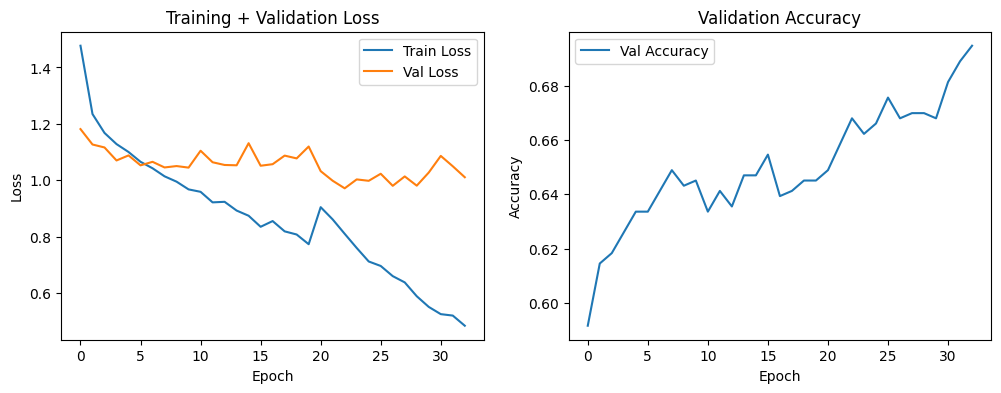

In [ ]:
from VitClassifier_1_defnitions import *

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = MultimodalModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

# === STAGE 1: Freeze ViT backbone, train metadata + classifier ===
freeze_backbone_multimodal(wrapper_model)  # correct function

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/ViT_1_multimodal_best_stage1.pt"
)

# === STAGE 2: Unfreeze everything ===
unfreeze_all_multimodal(wrapper_model)

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/ViT_1_multimodal_best_stage2.pt"
)

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

## 1.2. Learned feature fusing using concatenation

Clinical close-up image + full metadata (skin, sex, site, age)

The architecture of the image and metadata encoders is the same - ViT backbone for the image and FC layers for the metadata.
However, instead of multiplication and preserving the dimension of 512 as an input of the wrapper, here we concat the embeddings and achieve a new input of size 1024.


Using device: cuda
metadata input dimension: 34
Epoch [1/1000] | Train Loss: 1.4051 | Val Loss: 1.2124 | Val Acc: 0.5954
Best model + history saved
Epoch [2/1000] | Train Loss: 1.2015 | Val Loss: 1.1264 | Val Acc: 0.6221
Best model + history saved
Epoch [3/1000] | Train Loss: 1.1376 | Val Loss: 1.0908 | Val Acc: 0.6298
Best model + history saved
Epoch [4/1000] | Train Loss: 1.1109 | Val Loss: 1.0504 | Val Acc: 0.6336
Best model + history saved
Epoch [5/1000] | Train Loss: 1.0624 | Val Loss: 1.0592 | Val Acc: 0.6355
Epoch [6/1000] | Train Loss: 1.0209 | Val Loss: 1.1024 | Val Acc: 0.6412
Epoch [7/1000] | Train Loss: 1.0121 | Val Loss: 1.0351 | Val Acc: 0.6450
Best model + history saved
Epoch [8/1000] | Train Loss: 0.9860 | Val Loss: 1.0304 | Val Acc: 0.6393
Best model + history saved
Epoch [9/1000] | Train Loss: 0.9841 | Val Loss: 1.0281 | Val Acc: 0.6279
Best model + history saved
Epoch [10/1000] | Train Loss: 0.9413 | Val Loss: 1.0473 | Val Acc: 0.6393
Epoch [11/1000] | Train Loss: 0.

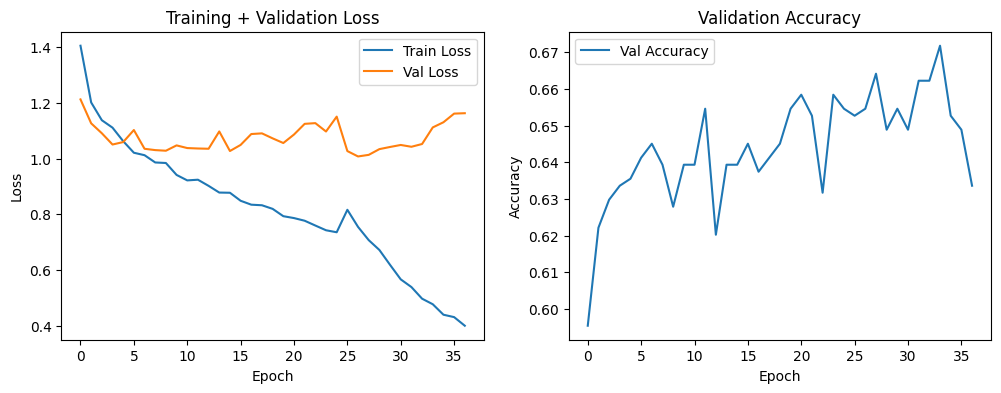

In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = MultimodalModel_concat(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

# === STAGE 1: Freeze ViT backbone, train metadata + classifier ===
freeze_backbone_multimodal(wrapper_model)  # correct function

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/ViT_2_multimodal_best_stage1.pt"
)

# === STAGE 2: Unfreeze everything ===
unfreeze_all_multimodal(wrapper_model)

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/ViT_2_multimodal_best_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

In [ ]:
elapsed_seconds = end_time - start_time

# --- Print elapsed time ---
hours, rem = divmod(elapsed_seconds, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Training finished in {int(hours)}h {int(minutes)}m {seconds:.2f}s on {device}")

Training finished in 0h 59m 51.11s on cuda


## 1.3 CrossAttention fusion
Clinical close-up + full metadata (skin, sex, age, site)

ViT backbone for Clinical close-up image and cross attention where the metadata is used for query, and the image is used for key and value.

Using device: cuda
metadata input dimension: 34
Epoch [1/1000] | Train Loss: 1.4563 | Val Loss: 1.2299 | Val Acc: 0.6107
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1665 | Val Loss: 1.1186 | Val Acc: 0.6107
Best model + history saved
Epoch [3/1000] | Train Loss: 1.0973 | Val Loss: 1.0916 | Val Acc: 0.6355
Best model + history saved
Epoch [4/1000] | Train Loss: 1.0549 | Val Loss: 1.0384 | Val Acc: 0.6355
Best model + history saved
Epoch [5/1000] | Train Loss: 1.0181 | Val Loss: 1.0538 | Val Acc: 0.6431
Epoch [6/1000] | Train Loss: 0.9798 | Val Loss: 1.0245 | Val Acc: 0.6508
Best model + history saved
Epoch [7/1000] | Train Loss: 0.9669 | Val Loss: 1.0393 | Val Acc: 0.6603
Epoch [8/1000] | Train Loss: 0.9559 | Val Loss: 1.0099 | Val Acc: 0.6527
Best model + history saved
Epoch [9/1000] | Train Loss: 0.9341 | Val Loss: 1.0046 | Val Acc: 0.6622
Best model + history saved
Epoch [10/1000] | Train Loss: 0.9121 | Val Loss: 1.0170 | Val Acc: 0.6527
Epoch [11/1000] | Train Loss: 0.

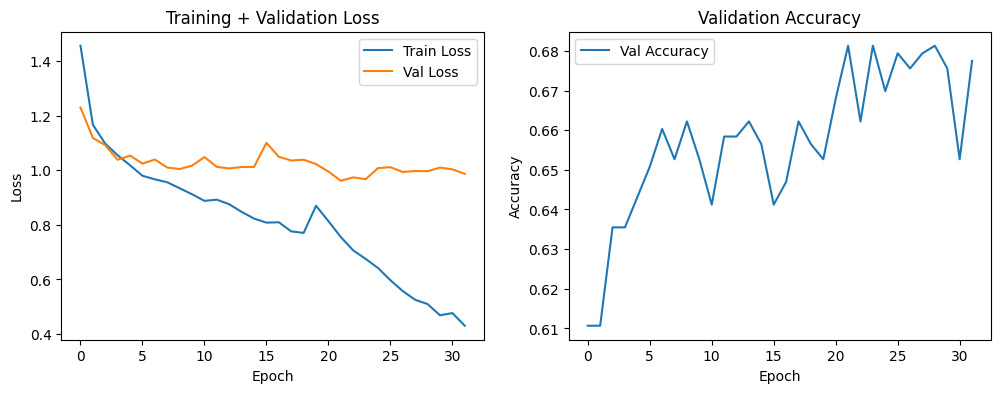

In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

# STAGE 1: freeze ViT
for param in wrapper_model.vit.parameters():
    param.requires_grad = False

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_1_multimodal_best_stage1.pt"
)

# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_1_multimodal_best_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

In [ ]:
elapsed_seconds = end_time - start_time

# --- Print elapsed time ---
hours, rem = divmod(elapsed_seconds, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Training finished in {int(hours)}h {int(minutes)}m {seconds:.2f}s on {device}")

Training finished in 0h 56m 59.36s on cuda


Run 2

In [11]:
from VitClassifier_1_defnitions import *
import time
import torch
import gc

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

# STAGE 1: freeze ViT
for param in wrapper_model.vit.parameters():
    param.requires_grad = False

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_1_multimodal_best_run_2_stage1.pt"
)

del optimizer_stage1
gc.collect()
torch.cuda.empty_cache()

# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_1_multimodal_best_run_2_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

Using device: cuda
metadata input dimension: 34
Epoch [1/1000] | Train Loss: 1.4806 | Val Loss: 1.1741 | Val Acc: 0.6050
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1482 | Val Loss: 1.1170 | Val Acc: 0.6221
Best model + history saved
Epoch [3/1000] | Train Loss: 1.0885 | Val Loss: 1.0941 | Val Acc: 0.6088
Best model + history saved
Epoch [4/1000] | Train Loss: 1.0568 | Val Loss: 1.0939 | Val Acc: 0.6279
Best model + history saved
Epoch [5/1000] | Train Loss: 1.0307 | Val Loss: 1.0637 | Val Acc: 0.6279
Best model + history saved
Epoch [6/1000] | Train Loss: 0.9880 | Val Loss: 1.0222 | Val Acc: 0.6450
Best model + history saved
Epoch [7/1000] | Train Loss: 0.9634 | Val Loss: 1.0208 | Val Acc: 0.6355
Best model + history saved
Epoch [8/1000] | Train Loss: 0.9500 | Val Loss: 1.0514 | Val Acc: 0.6508
Epoch [9/1000] | Train Loss: 0.9284 | Val Loss: 1.0635 | Val Acc: 0.6412
Epoch [10/1000] | Train Loss: 0.8984 | Val Loss: 1.0425 | Val Acc: 0.6565
Epoch [11/1000] | Train Loss: 0.

NameError: name 'wrapper_model' is not defined

Continue from stage 2

Using device: cuda
metadata input dimension: 34
Epoch [1/1000] | Train Loss: 0.7413 | Val Loss: 0.9948 | Val Acc: 0.6527
Best model + history saved
Epoch [2/1000] | Train Loss: 0.6695 | Val Loss: 1.0031 | Val Acc: 0.6698
Epoch [3/1000] | Train Loss: 0.6278 | Val Loss: 0.9943 | Val Acc: 0.6622
Best model + history saved
Epoch [4/1000] | Train Loss: 0.5671 | Val Loss: 1.0465 | Val Acc: 0.6756
Epoch [5/1000] | Train Loss: 0.5514 | Val Loss: 1.0395 | Val Acc: 0.6622
Epoch [6/1000] | Train Loss: 0.5277 | Val Loss: 1.0260 | Val Acc: 0.6546
Epoch [7/1000] | Train Loss: 0.5095 | Val Loss: 0.9775 | Val Acc: 0.6794
Best model + history saved
Epoch [8/1000] | Train Loss: 0.4632 | Val Loss: 1.0130 | Val Acc: 0.6794
Epoch [9/1000] | Train Loss: 0.4389 | Val Loss: 1.0122 | Val Acc: 0.6584
Epoch [10/1000] | Train Loss: 0.4180 | Val Loss: 1.0042 | Val Acc: 0.6794
Epoch [11/1000] | Train Loss: 0.4021 | Val Loss: 1.0316 | Val Acc: 0.6775
Epoch [12/1000] | Train Loss: 0.3858 | Val Loss: 1.0274 | Val Acc:

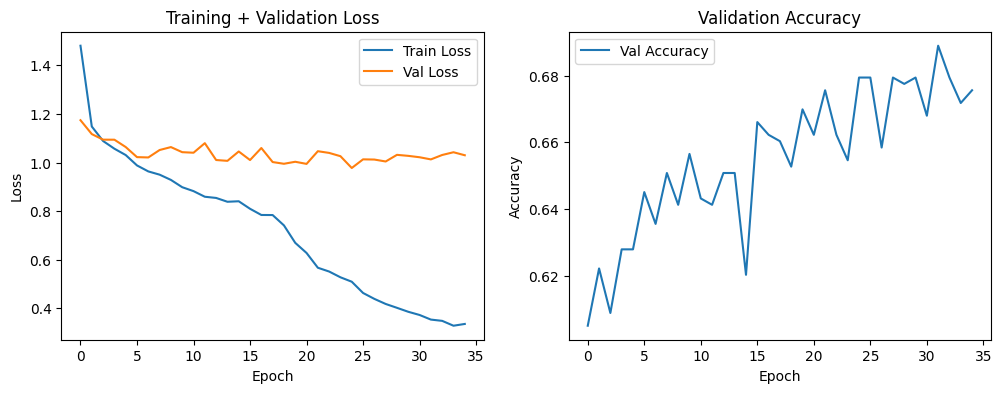

In [13]:
from VitClassifier_1_defnitions import *
import time
import torch
import gc

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)
model_filename = 'Cross_1_multimodal_best_run_2_stage1.pt'

# load the model as saved in the checkpoints dir:

checkpoint_path = CHECKPOINT_DIR + "/" + model_filename
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

# now load the actual model weights
wrapper_model.load_state_dict(checkpoint["model_state"])
history_stage1 = checkpoint["history"]

# Criterion
criterion = nn.CrossEntropyLoss()

# STAGE 1: freeze ViT
# for param in wrapper_model.vit.parameters():
#     param.requires_grad = False

# optimizer_stage1 = torch.optim.AdamW(
#     filter(lambda p: p.requires_grad, wrapper_model.parameters()),
#     lr=best_lr_head
# )

# wrapper_model, history_stage1 = train_model_multimodal(
#     wrapper_model,
#     train_loader,
#     val_loader,
#     criterion,
#     optimizer_stage1,
#     device,
#     epochs=1000,
#     patience=10,
#     save_path=f"{CHECKPOINT_DIR}/Cross_1_multimodal_best_run_2_stage1.pt"
# )

# del optimizer_stage1
# gc.collect()
# torch.cuda.empty_cache()


# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_1_multimodal_best_run_2_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

In [ ]:
del wrapper_model, optimizer_stage2, history_stage1, history_stage2
gc.collect()
torch.cuda.empty_cache()

Run 3

Using device: cuda
metadata input dimension: 34
Epoch [1/1000] | Train Loss: 1.5048 | Val Loss: 1.2208 | Val Acc: 0.6088
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1701 | Val Loss: 1.1332 | Val Acc: 0.6355
Best model + history saved
Epoch [3/1000] | Train Loss: 1.0971 | Val Loss: 1.1141 | Val Acc: 0.6317
Best model + history saved
Epoch [4/1000] | Train Loss: 1.0522 | Val Loss: 1.0755 | Val Acc: 0.6412
Best model + history saved
Epoch [5/1000] | Train Loss: 1.0348 | Val Loss: 1.0734 | Val Acc: 0.6431
Best model + history saved
Epoch [6/1000] | Train Loss: 0.9908 | Val Loss: 1.0182 | Val Acc: 0.6622
Best model + history saved
Epoch [7/1000] | Train Loss: 0.9716 | Val Loss: 1.0233 | Val Acc: 0.6508
Epoch [8/1000] | Train Loss: 0.9616 | Val Loss: 1.0340 | Val Acc: 0.6527
Epoch [9/1000] | Train Loss: 0.9249 | Val Loss: 1.0167 | Val Acc: 0.6508
Best model + history saved
Epoch [10/1000] | Train Loss: 0.9088 | Val Loss: 0.9842 | Val Acc: 0.6412
Best model + history saved
Epoch

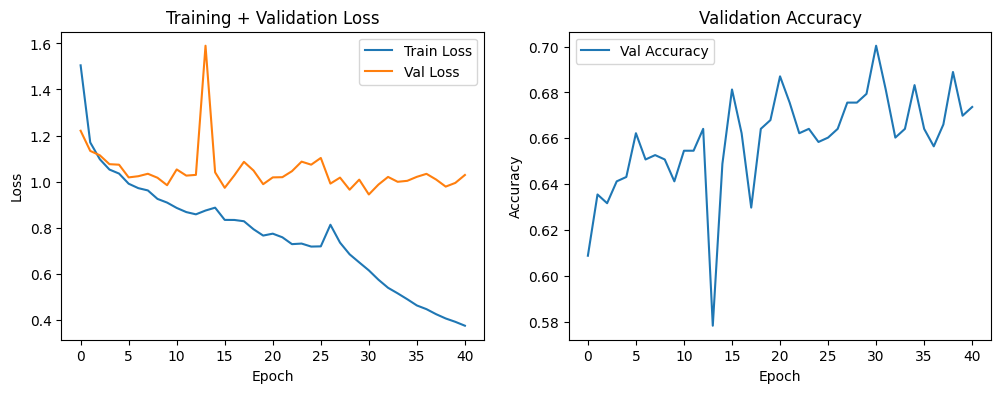

In [12]:
from VitClassifier_1_defnitions import *
import time
import torch

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

# STAGE 1: freeze ViT
for param in wrapper_model.vit.parameters():
    param.requires_grad = False

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_1_multimodal_best_run_3_stage1.pt"
)
del optimizer_stage1
gc.collect()
torch.cuda.empty_cache()

# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_1_multimodal_best_run_3_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

# 2. Clinical close-up image + reduced metadata (age, skin)

## Load data

In [ ]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "skin_tone_class"]

if False: # I have already created it and saved it, so shouldn't do it again.
  metadata_maps = build_metadata_maps(df_train_clinical_minimal, metadata_cols)

  # save the metadata maps:
  with open(WORK_DIR_ROOT + "/metadata_maps_age_skin.json", "w") as f:
    json.dump(metadata_maps, f, indent=2)


# load the maps, because almost certainly I'll have to rerun the whole colab:
with open(WORK_DIR_ROOT + "/metadata_maps_age_skin.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)


{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}}


In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()])

validation_transform = transforms.Compose([
    transforms.ToTensor()])

In [ ]:
from utils import Milk10kDataset_multimodal
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_dataset = Milk10kDataset_multimodal(
    df_train_clinical,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,   # None means automatically take all non-image/non-label columns
    transform=train_transform,
    smoothing=0.1         # adjust if you want more/less soft
)

val_dataset = Milk10kDataset_multimodal(
    df_val_clinical,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform,
    smoothing=0.1
)

NUM_WORKERS = os.cpu_count()

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

train_loader, val_loader

Using device: cuda


(<torch.utils.data.dataloader.DataLoader at 0x7a57a50d5f10>,
 <torch.utils.data.dataloader.DataLoader at 0x7a57a524eed0>)

In [ ]:
img, meta, label = next(iter(train_loader))

# Note that batch size will now be 1.
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")
print(f"Meta shape: {meta.shape}")

Image shape: torch.Size([32, 3, 224, 224]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])
Meta shape: torch.Size([32, 24])


In [ ]:
print("Meta shape:", meta.shape)
print("First 3 metadata vectors:\n", meta[:3])

Meta shape: torch.Size([32, 24])
First 3 metadata vectors:
 tensor([[0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500,
         0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.9000, 0.0500, 0.0500,
         0.0500, 0.0500, 0.0500, 0.9000, 0.0500, 0.0500],
        [0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500,
         0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.9000, 0.0500,
         0.0500, 0.0500, 0.0500, 0.9000, 0.0500, 0.0500],
        [0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500,
         0.0500, 0.0500, 0.9000, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500,
         0.0500, 0.0500, 0.0500, 0.9000, 0.0500, 0.0500]])


## Train models

## 2.1 Learned feature fusion using multiplication

Clinical close-up image + reduced metadata (skin, age)

Using device: cuda
metadata input dimension: 24
Epoch [1/1000] | Train Loss: 1.4759 | Val Loss: 1.2375 | Val Acc: 0.5878
Best model + history saved
Epoch [2/1000] | Train Loss: 1.2499 | Val Loss: 1.1436 | Val Acc: 0.6145
Best model + history saved
Epoch [3/1000] | Train Loss: 1.1874 | Val Loss: 1.1057 | Val Acc: 0.6393
Best model + history saved
Epoch [4/1000] | Train Loss: 1.1370 | Val Loss: 1.0854 | Val Acc: 0.6336
Best model + history saved
Epoch [5/1000] | Train Loss: 1.1260 | Val Loss: 1.0991 | Val Acc: 0.6317
Epoch [6/1000] | Train Loss: 1.1021 | Val Loss: 1.0849 | Val Acc: 0.6431
Best model + history saved
Epoch [7/1000] | Train Loss: 1.0861 | Val Loss: 1.0810 | Val Acc: 0.6279
Best model + history saved
Epoch [8/1000] | Train Loss: 1.0525 | Val Loss: 1.0517 | Val Acc: 0.6508
Best model + history saved
Epoch [9/1000] | Train Loss: 1.0410 | Val Loss: 1.0560 | Val Acc: 0.6431
Epoch [10/1000] | Train Loss: 1.0306 | Val Loss: 1.0693 | Val Acc: 0.6527
Epoch [11/1000] | Train Loss: 1.

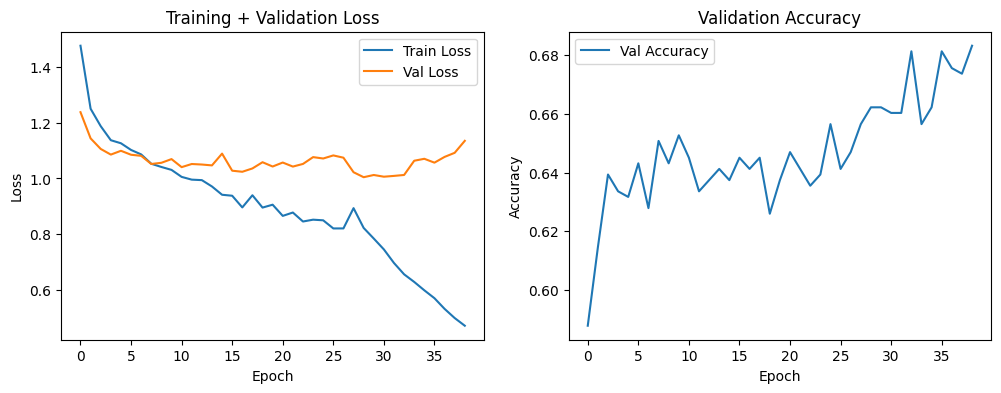

In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = MultimodalModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

# === STAGE 1: Freeze ViT backbone, train metadata + classifier ===
freeze_backbone_multimodal(wrapper_model)  # correct function

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/ViT_3_multimodal_best_stage1.pt"
)

# === STAGE 2: Unfreeze everything ===
unfreeze_all_multimodal(wrapper_model)

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/ViT_3_multimodal_best_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

In [ ]:
elapsed_seconds = end_time - start_time

# --- Print elapsed time ---
hours, rem = divmod(elapsed_seconds, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Training finished in {int(hours)}h {int(minutes)}m {seconds:.2f}s on {device}")

Training finished in 1h 2m 5.82s on cuda


## 2.2 Learned feature fusion using concatenation

Clinical close-up image + reduced metadata (skin, age)

Using device: cuda
metadata input dimension: 24
Epoch [1/1000] | Train Loss: 1.4045 | Val Loss: 1.1616 | Val Acc: 0.6145
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1914 | Val Loss: 1.1349 | Val Acc: 0.6164
Best model + history saved
Epoch [3/1000] | Train Loss: 1.1367 | Val Loss: 1.1061 | Val Acc: 0.6355
Best model + history saved
Epoch [4/1000] | Train Loss: 1.0981 | Val Loss: 1.0789 | Val Acc: 0.6336
Best model + history saved
Epoch [5/1000] | Train Loss: 1.0825 | Val Loss: 1.0866 | Val Acc: 0.6374
Epoch [6/1000] | Train Loss: 1.0526 | Val Loss: 1.0540 | Val Acc: 0.6355
Best model + history saved
Epoch [7/1000] | Train Loss: 1.0320 | Val Loss: 1.0684 | Val Acc: 0.6469
Epoch [8/1000] | Train Loss: 1.0071 | Val Loss: 1.0547 | Val Acc: 0.6374
Epoch [9/1000] | Train Loss: 1.0302 | Val Loss: 1.0319 | Val Acc: 0.6469
Best model + history saved
Epoch [10/1000] | Train Loss: 0.9815 | Val Loss: 1.0859 | Val Acc: 0.6260
Epoch [11/1000] | Train Loss: 0.9795 | Val Loss: 1.0239 | V

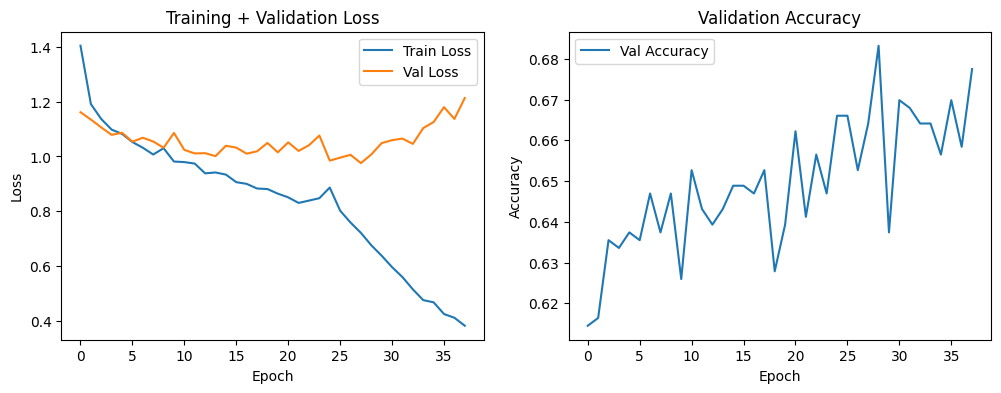

In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = MultimodalModel_concat(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

# === STAGE 1: Freeze ViT backbone, train metadata + classifier ===
freeze_backbone_multimodal(wrapper_model)  # correct function

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/ViT_4_multimodal_best_stage1.pt"
)

# === STAGE 2: Unfreeze everything ===
unfreeze_all_multimodal(wrapper_model)

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/ViT_4_multimodal_best_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

In [ ]:
elapsed_seconds = end_time - start_time

# --- Print elapsed time ---
hours, rem = divmod(elapsed_seconds, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Training finished in {int(hours)}h {int(minutes)}m {seconds:.2f}s on {device}")

Training finished in 1h 4m 7.77s on cuda


## 2.3 CrossAttention fusion
Clinical close-up images + reduced metadata (skin, age)

ViT backbone for Clinical close-up image and cross attention where the metadata is used for query, and the image is used for key and value.

Using device: cuda
metadata input dimension: 24
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 175MB/s]


Epoch [1/1000] | Train Loss: 1.5927 | Val Loss: 1.3657 | Val Acc: 0.5611
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1841 | Val Loss: 1.1596 | Val Acc: 0.6088
Best model + history saved
Epoch [3/1000] | Train Loss: 1.1112 | Val Loss: 1.0801 | Val Acc: 0.6221
Best model + history saved
Epoch [4/1000] | Train Loss: 1.0775 | Val Loss: 1.0988 | Val Acc: 0.6336
Epoch [5/1000] | Train Loss: 1.0243 | Val Loss: 1.0800 | Val Acc: 0.6508
Best model + history saved
Epoch [6/1000] | Train Loss: 1.0094 | Val Loss: 1.0688 | Val Acc: 0.6107
Best model + history saved
Epoch [7/1000] | Train Loss: 0.9821 | Val Loss: 1.0779 | Val Acc: 0.6336
Epoch [8/1000] | Train Loss: 0.9640 | Val Loss: 1.0826 | Val Acc: 0.6527
Epoch [9/1000] | Train Loss: 0.9637 | Val Loss: 1.0216 | Val Acc: 0.6603
Best model + history saved
Epoch [10/1000] | Train Loss: 0.9251 | Val Loss: 1.0257 | Val Acc: 0.6603
Epoch [11/1000] | Train Loss: 0.9181 | Val Loss: 1.0167 | Val Acc: 0.6622
Best model + history saved
Epoch 

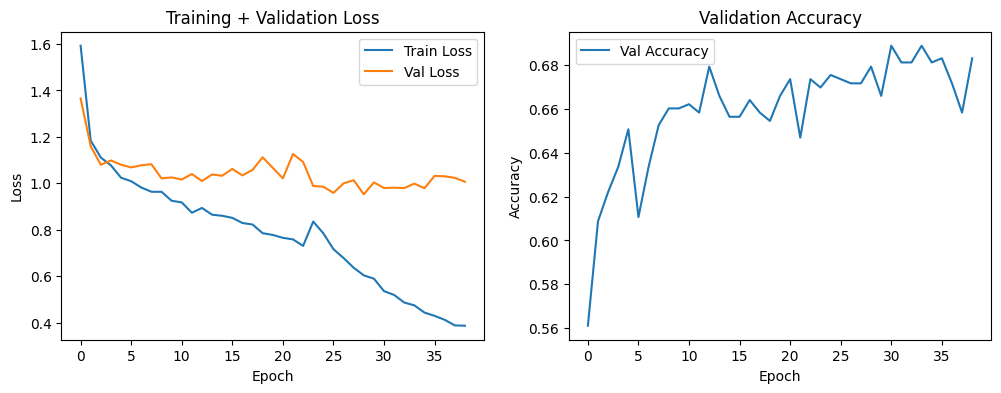

In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch

# --- Check device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

metadata_input_dim = next(iter(train_loader))[1].shape[1]
print(f"metadata input dimension: {metadata_input_dim}")

# Initialize wrapper
wrapper_model = CrossAttentionModel(metadata_input_dim, num_classes=11).to(device)

# Criterion
criterion = nn.CrossEntropyLoss()

# STAGE 1: freeze ViT
for param in wrapper_model.vit.parameters():
    param.requires_grad = False

optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_2_multimodal_best_stage1.pt"
)

# STAGE 2: unfreeze everything
for param in wrapper_model.parameters():
    param.requires_grad = True

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_multimodal(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_2_multimodal_best_stage2.pt"
)

# --- End timer ---
end_time = time.time()

# === PLOT TRAINING HISTORY ===
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

In [ ]:
elapsed_seconds = end_time - start_time

# --- Print elapsed time ---
hours, rem = divmod(elapsed_seconds, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Training finished in {int(hours)}h {int(minutes)}m {seconds:.2f}s on {device}")

Training finished in 1h 25m 16.38s on cuda


# 3. Clinical close-up images + dermoscopic images

## Load data

In [ ]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

df_train_dermoscopic_minimal = (
    df_train_orig[df_train_orig["image_type"] == "dermoscopic"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

print(df_train_clinical_minimal.head())

df_train_dermoscopic_minimal = df_train_dermoscopic_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)
print(df_train_dermoscopic_minimal.head())

print((df_train_clinical_minimal["label_id"] == df_train_dermoscopic_minimal["label_id"]).all())

    lesion_id       isic_id          image_type  label_id
0  IL_0000652  ISIC_8149219  clinical: close-up         1
1  IL_0003176  ISIC_3904045  clinical: close-up         1
2  IL_0004688  ISIC_0791494  clinical: close-up         1
3  IL_0005081  ISIC_5667730  clinical: close-up         9
4  IL_0006177  ISIC_8803389  clinical: close-up         1
    lesion_id       isic_id   image_type  label_id
0  IL_0000652  ISIC_4671410  dermoscopic         1
1  IL_0003176  ISIC_5371928  dermoscopic         1
2  IL_0004688  ISIC_3624913  dermoscopic         1
3  IL_0005081  ISIC_5186409  dermoscopic         9
4  IL_0006177  ISIC_1048297  dermoscopic         1
True


#### Import the lession Ids split

In [ ]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# Clinical close-up images:

# Train
df_train_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(train_lesions)
].reset_index(drop=True)

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)


# Dermoscopic images:

# Train
df_train_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(train_lesions)
].reset_index(drop=True)

# Validation
df_val_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)



Lesions - Train: 4191, Val: 524, Test: 525


#### Create the data transformers

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()])

validation_transform = transforms.Compose([
    transforms.ToTensor()])

#### Create the data loaders

In [ ]:
from utils import Milk10kDataset_images
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_dataset = Milk10kDataset_images(
    df_train_clinical,
    df_train_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    transform=train_transform
)

val_dataset = Milk10kDataset_images(
    df_val_clinical,
    df_val_dermoscopic,
    root_dir=DATASET_RESIZED + "/validation",
    transform=validation_transform
)

NUM_WORKERS = os.cpu_count()

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

train_loader, val_loader

Using device: cuda


(<torch.utils.data.dataloader.DataLoader at 0x7e968a62cd70>,
 <torch.utils.data.dataloader.DataLoader at 0x7e969e5714c0>)

## Train models

## 3.1 Mutual cross attention

Clinical close-up images + dermoscopic images

With ViT backbone for clinical and dermoscopic images, where we use Cross attention with first clinical images as queries and dermoscopic images as key and value, and then the opposite.

Using device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 193MB/s]


Epoch [1/1000] | Train Loss: 1.4128 | Val Loss: 1.2154 | Val Acc: 0.6240
Best model + history saved
Epoch [2/1000] | Train Loss: 1.0980 | Val Loss: 1.0583 | Val Acc: 0.6584
Best model + history saved
Epoch [3/1000] | Train Loss: 1.0242 | Val Loss: 1.0090 | Val Acc: 0.6679
Best model + history saved
Epoch [4/1000] | Train Loss: 0.9916 | Val Loss: 1.1837 | Val Acc: 0.5649
Epoch [5/1000] | Train Loss: 0.9648 | Val Loss: 1.0025 | Val Acc: 0.6851
Best model + history saved
Epoch [6/1000] | Train Loss: 0.9000 | Val Loss: 0.9243 | Val Acc: 0.6832
Best model + history saved
Epoch [7/1000] | Train Loss: 0.8919 | Val Loss: 0.9509 | Val Acc: 0.6908
Epoch [8/1000] | Train Loss: 0.8526 | Val Loss: 0.9085 | Val Acc: 0.7023
Best model + history saved
Epoch [9/1000] | Train Loss: 0.8266 | Val Loss: 0.9380 | Val Acc: 0.6927
Epoch [10/1000] | Train Loss: 0.8293 | Val Loss: 0.9631 | Val Acc: 0.6737
Epoch [11/1000] | Train Loss: 0.7925 | Val Loss: 1.0145 | Val Acc: 0.6660
Epoch [12/1000] | Train Loss: 0.7

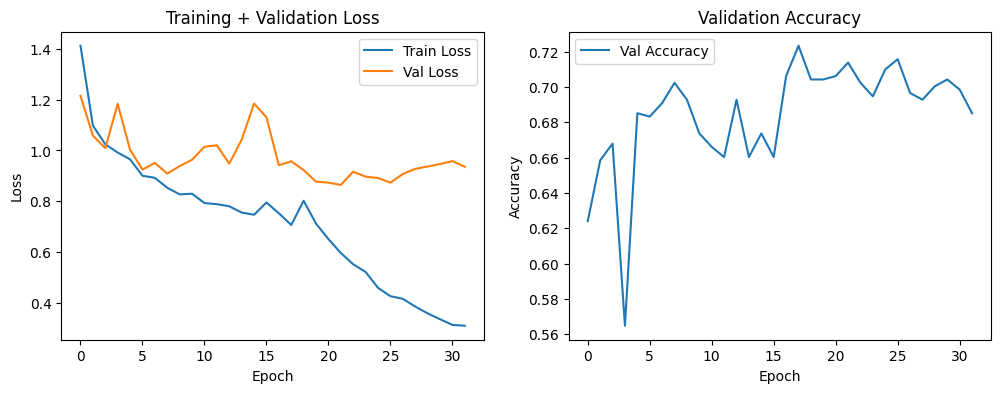

In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.0004615619914925977
best_lr_full = 1.1526026851977796e-05

wrapper_model = MutualCrossAttentionModel_images(num_classes=11).to(device)

criterion = nn.CrossEntropyLoss()


# STAGE 1: Freeze BOTH ViT backbones
freeze_backbone_images(wrapper_model)

# Train only projections + attention + head
optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_images(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_images_1_best_stage1.pt"
)

# STAGE 2: Unfreeze everything
unfreeze_all_images(wrapper_model)

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_images(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_images_1_best_stage2.pt"
)

# --- End timer ---
end_time = time.time()

print(f"Total training time: {(end_time - start_time)/60:.2f} minutes")

# Plot
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

# 4. Clinical close-up image + dermoscopic image + full metadata (sex, age, skin, site)

## Load data

In [ ]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type", "age_approx", "skin_tone_class", "sex", "site"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

df_train_dermoscopic_minimal = (
    df_train_orig[df_train_orig["image_type"] == "dermoscopic"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

print(df_train_clinical_minimal.head())

df_train_dermoscopic_minimal = df_train_dermoscopic_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)
print(df_train_dermoscopic_minimal.head())

print((df_train_clinical_minimal["label_id"] == df_train_dermoscopic_minimal["label_id"]).all())

    lesion_id       isic_id          image_type  age_approx  skin_tone_class  \
0  IL_0000652  ISIC_8149219  clinical: close-up        70.0                1   
1  IL_0003176  ISIC_3904045  clinical: close-up        45.0                5   
2  IL_0004688  ISIC_0791494  clinical: close-up        50.0                3   
3  IL_0005081  ISIC_5667730  clinical: close-up        45.0                3   
4  IL_0006177  ISIC_8803389  clinical: close-up        75.0                3   

      sex             site  label_id  
0    male   head_neck_face         1  
1  female   head_neck_face         1  
2    male  lower_extremity         1  
3    male   head_neck_face         9  
4    male  upper_extremity         1  
    lesion_id       isic_id   image_type  age_approx  skin_tone_class     sex  \
0  IL_0000652  ISIC_4671410  dermoscopic        70.0                1    male   
1  IL_0003176  ISIC_5371928  dermoscopic        45.0                5  female   
2  IL_0004688  ISIC_3624913  dermoscopic  

#### Import the lession Ids split

In [ ]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# Clinical close-up images:

# Train
df_train_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(train_lesions)
].reset_index(drop=True)

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)


# Dermoscopic images:

# Train
df_train_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(train_lesions)
].reset_index(drop=True)

# Validation
df_val_dermoscopic = df_train_dermoscopic_minimal[
    df_train_dermoscopic_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)



Lesions - Train: 4191, Val: 524, Test: 525


#### Load the mapping between metadata values and their location in the one-hot-encoding vector

In [ ]:
from utils import build_metadata_maps

metadata_cols = ["age_approx", "sex", "skin_tone_class", "site"]

if False: # I have already created it and saved it, so shouldn't do it again.
  metadata_maps = build_metadata_maps(df_train_clinical_minimal, metadata_cols)

  # save the metadata maps:
  with open(WORK_DIR_ROOT + "/metadata_maps.json", "w") as f:
    json.dump(metadata_maps, f, indent=2)

# load the maps, because almost certainly I'll have to rerun the whole colab:
with open(WORK_DIR_ROOT + "/metadata_maps.json", "r") as f:
    metadata_maps = json.load(f)
    print(metadata_maps)

{'age_approx': {'10.0': 0, '15.0': 1, '20.0': 2, '25.0': 3, '30.0': 4, '35.0': 5, '40.0': 6, '45.0': 7, '5.0': 8, '50.0': 9, '55.0': 10, '60.0': 11, '65.0': 12, '70.0': 13, '75.0': 14, '80.0': 15, '85.0': 16, 'MISSING': 17}, 'sex': {'female': 0, 'male': 1}, 'skin_tone_class': {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}, 'site': {'MISSING': 0, 'foot': 1, 'genital': 2, 'hand': 3, 'head_neck_face': 4, 'lower_extremity': 5, 'trunk': 6, 'upper_extremity': 7}}


#### Create the data transformers

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()])

validation_transform = transforms.Compose([
    transforms.ToTensor()])

#### Create the datasets to be used in the dataloaders

In [ ]:
from utils import Milk10kDataset_3_modalities
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


train_dataset = Milk10kDataset_3_modalities(
    df_train_clinical,
    df_train_dermoscopic,
    root_dir=DATASET_RESIZED + "/train",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=train_transform
)

val_dataset = Milk10kDataset_3_modalities(
    df_val_clinical,
    df_val_dermoscopic,
    root_dir=DATASET_RESIZED + "/validation",
    metadata_maps=metadata_maps,
    metadata_cols=metadata_cols,
    transform=validation_transform
)


Using device: cuda


## Train models

## 4.1 Mututal cross attention and metadata fusion
Clinical close-up image + dermoscopic image + full metadata (skin, sex, age, site)

### Optuna for parameter search

In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.4 MB/s eta 0:00:00


In [ ]:
import optuna
import torch.nn as nn
from VitClassifier_1_defnitions import *
import os

NUM_WORKERS = os.cpu_count()

def objective(trial):
    lr_head = trial.suggest_float("lr_head", 1e-4, 1e-3)
    lr_full = trial.suggest_float("lr_full", 1e-5, 1e-4)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    # Rebuild dataloaders
    train_loader = DataLoader(
      train_dataset,
      batch_size=batch_size,
      shuffle=True,
      num_workers=NUM_WORKERS,
      pin_memory=True
    )

    val_loader = DataLoader(
      val_dataset,
      batch_size=batch_size,
      shuffle=False,
      num_workers=NUM_WORKERS,
      pin_memory=True
    )

    model = MutualCrossAttentionModel_3modalities(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    # STAGE 1: HEAD ONLY
    freeze_backbone_3_modalities(model)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_head
    )

    train_model_3_modalities(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=7,
        patience=3,
        save_path=None
    )

    # STAGE 2: FULL MODEL
    unfreeze_all_3_modalities(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_full
    )

    train_model_3_modalities(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=7,
        patience=3,
        save_path=None
    )

    # Final evaluation
    _, val_acc = evaluate_3_modalities(
        model,
        val_loader,
        criterion,
        device
    )

    return val_acc

############# Run the study:
if True:
  study = optuna.create_study(
      direction="maximize"
  )

  study.optimize(
      objective,
      n_trials=8,
      timeout=None          # optional
  )

  print("Best validation accuracy:", study.best_value)
  print("Best hyperparameters:", study.best_params)

[I 2026-04-10 10:36:55,528] A new study created in memory with name: no-name-0539d694-ea34-40df-933f-4940292589f2


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 178MB/s]


Epoch [1/7] | Train Loss: 1.3543 | Val Loss: 1.1294 | Val Acc: 0.6011
Epoch [2/7] | Train Loss: 1.1638 | Val Loss: 1.0675 | Val Acc: 0.6489
Epoch [3/7] | Train Loss: 1.1065 | Val Loss: 1.1805 | Val Acc: 0.5573
Epoch [4/7] | Train Loss: 1.0794 | Val Loss: 0.9864 | Val Acc: 0.6813
Epoch [5/7] | Train Loss: 1.0573 | Val Loss: 1.0589 | Val Acc: 0.6603
Epoch [6/7] | Train Loss: 1.1261 | Val Loss: 1.3826 | Val Acc: 0.5802
Epoch [7/7] | Train Loss: 1.0992 | Val Loss: 1.1070 | Val Acc: 0.6279
Early stopping triggered
Epoch [1/7] | Train Loss: 1.2249 | Val Loss: 1.1192 | Val Acc: 0.6412
Epoch [2/7] | Train Loss: 1.1264 | Val Loss: 1.1961 | Val Acc: 0.6355
Epoch [3/7] | Train Loss: 1.1123 | Val Loss: 1.0409 | Val Acc: 0.6565
Epoch [4/7] | Train Loss: 1.0748 | Val Loss: 1.1278 | Val Acc: 0.6183
Epoch [5/7] | Train Loss: 1.2397 | Val Loss: 1.9469 | Val Acc: 0.4332
Epoch [6/7] | Train Loss: 1.2376 | Val Loss: 3.3937 | Val Acc: 0.4847
Early stopping triggered


[I 2026-04-10 12:17:36,129] Trial 0 finished with value: 0.6564885496183206 and parameters: {'lr_head': 0.0005164964328173245, 'lr_full': 5.4305809728440795e-05, 'batch_size': 16}. Best is trial 0 with value: 0.6564885496183206.


...

Epoch [1/7] | Train Loss: 1.3627 | Val Loss: 1.8965 | Val Acc: 0.5267
Epoch [2/7] | Train Loss: 1.2321 | Val Loss: 1.6765 | Val Acc: 0.4237
Epoch [3/7] | Train Loss: 1.2505 | Val Loss: 1.2822 | Val Acc: 0.5706
Epoch [4/7] | Train Loss: 1.2299 | Val Loss: 3.0332 | Val Acc: 0.1927
Epoch [5/7] | Train Loss: 1.1841 | Val Loss: 1.1889 | Val Acc: 0.5954
Epoch [6/7] | Train Loss: 1.2273 | Val Loss: 1.1729 | Val Acc: 0.6088
Epoch [7/7] | Train Loss: 1.1764 | Val Loss: 1.3055 | Val Acc: 0.6183
Epoch [1/7] | Train Loss: 1.3311 | Val Loss: 1.2510 | Val Acc: 0.5954
Epoch [2/7] | Train Loss: 1.3356 | Val Loss: 1.3448 | Val Acc: 0.5821
Epoch [3/7] | Train Loss: 1.2780 | Val Loss: 1.4378 | Val Acc: 0.5324
Epoch [4/7] | Train Loss: 1.2960 | Val Loss: 1.2631 | Val Acc: 0.5706
Early stopping triggered


[I 2026-04-10 18:52:22,196] Trial 6 finished with value: 0.5954198473282443 and parameters: {'lr_head': 0.0009361432194539954, 'lr_full': 3.846698586018997e-05, 'batch_size': 16}. Best is trial 4 with value: 0.6622137404580153.


Epoch [1/7] | Train Loss: 1.3336 | Val Loss: 1.3954 | Val Acc: 0.5935
Epoch [2/7] | Train Loss: 1.2766 | Val Loss: 1.6073 | Val Acc: 0.2805
Epoch [3/7] | Train Loss: 1.2404 | Val Loss: 1.2872 | Val Acc: 0.5477
Epoch [4/7] | Train Loss: 1.1812 | Val Loss: 1.1933 | Val Acc: 0.6069
Epoch [5/7] | Train Loss: 1.1680 | Val Loss: 1.2039 | Val Acc: 0.5878
Epoch [6/7] | Train Loss: 1.1396 | Val Loss: 1.5515 | Val Acc: 0.4256
Epoch [7/7] | Train Loss: 1.1348 | Val Loss: 1.4318 | Val Acc: 0.4466
Early stopping triggered
Epoch [1/7] | Train Loss: 1.7539 | Val Loss: 1.8874 | Val Acc: 0.2958
Epoch [2/7] | Train Loss: 1.5597 | Val Loss: 1.7850 | Val Acc: 0.4504
Epoch [3/7] | Train Loss: 1.5404 | Val Loss: 1.8057 | Val Acc: 0.4847
Epoch [4/7] | Train Loss: 1.5105 | Val Loss: 1.4060 | Val Acc: 0.5534
Epoch [5/7] | Train Loss: 1.5294 | Val Loss: 1.4927 | Val Acc: 0.4866
Epoch [6/7] | Train Loss: 1.5929 | Val Loss: 1.5686 | Val Acc: 0.4866
Epoch [7/7] | Train Loss: 1.4817 | Val Loss: 1.5446 | Val Acc: 0.

[I 2026-04-10 20:10:26,889] Trial 7 finished with value: 0.5534351145038168 and parameters: {'lr_head': 0.0009330727436137886, 'lr_full': 7.640323174403788e-05, 'batch_size': 16}. Best is trial 4 with value: 0.6622137404580153.


Best validation accuracy: 0.6622137404580153
Best hyperparameters: {'lr_head': 0.00045353929952135025, 'lr_full': 4.4218448973890505e-05, 'batch_size': 16}


Best validation accuracy: 0.6622137404580153
Best hyperparameters: {'lr_head': 0.00045353929952135025, 'lr_full': 4.4218448973890505e-05, 'batch_size': 16}


In [ ]:
!pip install optuna -q

In [ ]:
import optuna
import torch.nn as nn
from VitClassifier_1_defnitions import *
import os

NUM_WORKERS = os.cpu_count()

# Rebuild dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

def objective(trial):
    lr_head = trial.suggest_float("lr_head", 1e-4, 1e-3)
    lr_full = trial.suggest_float("lr_full", 1e-5, 1e-4)


    model = MutualCrossAttentionModel_3modalities(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    # STAGE 1: HEAD ONLY
    freeze_backbone_3_modalities(model)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_head
    )

    train_model_3_modalities(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=7,
        patience=3,
        save_path=None
    )

    # STAGE 2: FULL MODEL
    unfreeze_all_3_modalities(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_full
    )

    train_model_3_modalities(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=7,
        patience=3,
        save_path=None
    )

    # Final evaluation
    _, val_acc = evaluate_3_modalities(
        model,
        val_loader,
        criterion,
        device
    )

    return val_acc

############# Run the study:
if True:
  study = optuna.create_study(
      direction="maximize"
  )

  study.optimize(
      objective,
      n_trials=8,
      timeout=None          # optional
  )

  print("Best validation accuracy:", study.best_value)
  print("Best hyperparameters:", study.best_params)

[I 2026-04-10 20:12:08,249] A new study created in memory with name: no-name-836a4594-396d-4da1-a419-21538aa02b39


Epoch [1/7] | Train Loss: 1.6759 | Val Loss: 1.2268 | Val Acc: 0.6450
Epoch [2/7] | Train Loss: 1.1724 | Val Loss: 1.0953 | Val Acc: 0.6450
Epoch [3/7] | Train Loss: 1.0527 | Val Loss: 1.0179 | Val Acc: 0.6794
Epoch [4/7] | Train Loss: 1.0108 | Val Loss: 1.0424 | Val Acc: 0.6469
Epoch [5/7] | Train Loss: 0.9553 | Val Loss: 0.9930 | Val Acc: 0.6870
Epoch [6/7] | Train Loss: 0.9145 | Val Loss: 0.9857 | Val Acc: 0.6584
Epoch [7/7] | Train Loss: 0.9058 | Val Loss: 0.9434 | Val Acc: 0.6889
Epoch [1/7] | Train Loss: 1.1554 | Val Loss: 1.1536 | Val Acc: 0.6412
Epoch [2/7] | Train Loss: 1.0440 | Val Loss: 1.3625 | Val Acc: 0.4504
Epoch [3/7] | Train Loss: 1.0122 | Val Loss: 1.0739 | Val Acc: 0.6584
Epoch [4/7] | Train Loss: 0.9331 | Val Loss: 1.1653 | Val Acc: 0.6355
Epoch [5/7] | Train Loss: 0.9160 | Val Loss: 1.0446 | Val Acc: 0.6374
Epoch [6/7] | Train Loss: 0.9005 | Val Loss: 0.9753 | Val Acc: 0.6565
Epoch [7/7] | Train Loss: 0.8222 | Val Loss: 1.0368 | Val Acc: 0.6584


[I 2026-04-10 21:10:14,271] Trial 0 finished with value: 0.6564885496183206 and parameters: {'lr_head': 0.00024274958603714026, 'lr_full': 9.331689782347274e-05}. Best is trial 0 with value: 0.6564885496183206.


Epoch [1/7] | Train Loss: 1.4203 | Val Loss: 1.1299 | Val Acc: 0.6527
Epoch [2/7] | Train Loss: 1.1281 | Val Loss: 1.1723 | Val Acc: 0.6393
Epoch [3/7] | Train Loss: 1.0467 | Val Loss: 1.0275 | Val Acc: 0.6508
Epoch [4/7] | Train Loss: 1.0205 | Val Loss: 1.0617 | Val Acc: 0.6489
Epoch [5/7] | Train Loss: 0.9749 | Val Loss: 0.9583 | Val Acc: 0.6660
Epoch [6/7] | Train Loss: 0.9328 | Val Loss: 1.1361 | Val Acc: 0.6050
Epoch [7/7] | Train Loss: 0.9356 | Val Loss: 1.0865 | Val Acc: 0.6164
Epoch [1/7] | Train Loss: 0.9393 | Val Loss: 0.9298 | Val Acc: 0.6851
Epoch [2/7] | Train Loss: 0.8505 | Val Loss: 0.9785 | Val Acc: 0.6851
Epoch [3/7] | Train Loss: 0.7724 | Val Loss: 0.9521 | Val Acc: 0.6832
Epoch [4/7] | Train Loss: 0.7129 | Val Loss: 0.9021 | Val Acc: 0.7042
Epoch [5/7] | Train Loss: 0.6640 | Val Loss: 0.9184 | Val Acc: 0.6927
Epoch [6/7] | Train Loss: 0.6145 | Val Loss: 0.9220 | Val Acc: 0.7061
Epoch [7/7] | Train Loss: 0.5682 | Val Loss: 0.9519 | Val Acc: 0.6966
Early stopping trigg

[I 2026-04-10 22:08:20,722] Trial 1 finished with value: 0.7041984732824428 and parameters: {'lr_head': 0.0005367195343861373, 'lr_full': 1.369310361613032e-05}. Best is trial 1 with value: 0.7041984732824428.


...

Epoch [1/7] | Train Loss: 1.5372 | Val Loss: 1.2059 | Val Acc: 0.6069
Epoch [2/7] | Train Loss: 1.1371 | Val Loss: 1.0942 | Val Acc: 0.6565
Epoch [3/7] | Train Loss: 1.0527 | Val Loss: 1.0709 | Val Acc: 0.6527
Epoch [4/7] | Train Loss: 1.0061 | Val Loss: 1.0052 | Val Acc: 0.6584
Epoch [5/7] | Train Loss: 0.9758 | Val Loss: 1.0147 | Val Acc: 0.6718
Epoch [6/7] | Train Loss: 0.9454 | Val Loss: 0.9656 | Val Acc: 0.6813
Epoch [7/7] | Train Loss: 0.8990 | Val Loss: 0.9628 | Val Acc: 0.6775
Epoch [1/7] | Train Loss: 1.0550 | Val Loss: 1.0873 | Val Acc: 0.6546
Epoch [2/7] | Train Loss: 0.9886 | Val Loss: 1.0806 | Val Acc: 0.6202
Epoch [3/7] | Train Loss: 0.8933 | Val Loss: 0.9626 | Val Acc: 0.6794
Epoch [4/7] | Train Loss: 0.8303 | Val Loss: 1.0314 | Val Acc: 0.6469
Epoch [5/7] | Train Loss: 0.7709 | Val Loss: 0.9389 | Val Acc: 0.7042
Epoch [6/7] | Train Loss: 0.7012 | Val Loss: 1.0356 | Val Acc: 0.6832
Epoch [7/7] | Train Loss: 0.6598 | Val Loss: 0.9306 | Val Acc: 0.7061


[I 2026-04-11 02:35:33,172] Trial 6 finished with value: 0.7061068702290076 and parameters: {'lr_head': 0.00030995448268009645, 'lr_full': 5.816190742383745e-05}. Best is trial 6 with value: 0.7061068702290076.


Epoch [1/7] | Train Loss: 1.5092 | Val Loss: 1.1986 | Val Acc: 0.6260
Epoch [2/7] | Train Loss: 1.1396 | Val Loss: 1.1034 | Val Acc: 0.6508
Epoch [3/7] | Train Loss: 1.0575 | Val Loss: 1.0492 | Val Acc: 0.6469
Epoch [4/7] | Train Loss: 1.0076 | Val Loss: 0.9934 | Val Acc: 0.6756
Epoch [5/7] | Train Loss: 0.9432 | Val Loss: 1.0083 | Val Acc: 0.6317
Epoch [6/7] | Train Loss: 0.9201 | Val Loss: 0.9618 | Val Acc: 0.6698
Epoch [7/7] | Train Loss: 0.8982 | Val Loss: 0.9546 | Val Acc: 0.6908
Epoch [1/7] | Train Loss: 1.0761 | Val Loss: 1.1037 | Val Acc: 0.6565
Epoch [2/7] | Train Loss: 0.9533 | Val Loss: 0.9809 | Val Acc: 0.6737
Epoch [3/7] | Train Loss: 0.9059 | Val Loss: 0.9581 | Val Acc: 0.6889
Epoch [4/7] | Train Loss: 0.8236 | Val Loss: 0.9442 | Val Acc: 0.6947
Epoch [5/7] | Train Loss: 0.7378 | Val Loss: 0.9552 | Val Acc: 0.6718
Epoch [6/7] | Train Loss: 0.7087 | Val Loss: 1.0473 | Val Acc: 0.6832
Epoch [7/7] | Train Loss: 0.6375 | Val Loss: 1.0828 | Val Acc: 0.6527
Early stopping trigg

[I 2026-04-11 03:33:35,083] Trial 7 finished with value: 0.6946564885496184 and parameters: {'lr_head': 0.0002455501207931077, 'lr_full': 6.227649642003653e-05}. Best is trial 6 with value: 0.7061068702290076.


Best validation accuracy: 0.7061068702290076
Best hyperparameters: {'lr_head': 0.00030995448268009645, 'lr_full': 5.816190742383745e-05}


Best validation accuracy: 0.7061068702290076
Best hyperparameters: {'lr_head': 0.00030995448268009645, 'lr_full': 5.816190742383745e-05}



### Run full training with best parameters

Using device: cuda
Epoch [1/1000] | Train Loss: 1.5306 | Val Loss: 1.1819 | Val Acc: 0.6240
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1359 | Val Loss: 1.0781 | Val Acc: 0.6355
Best model + history saved
Epoch [3/1000] | Train Loss: 1.0606 | Val Loss: 1.1038 | Val Acc: 0.6431
Epoch [4/1000] | Train Loss: 1.0103 | Val Loss: 0.9986 | Val Acc: 0.6641
Best model + history saved
Epoch [5/1000] | Train Loss: 0.9720 | Val Loss: 0.9601 | Val Acc: 0.6698
Best model + history saved
Epoch [6/1000] | Train Loss: 0.9348 | Val Loss: 0.9936 | Val Acc: 0.6622
Epoch [7/1000] | Train Loss: 0.8837 | Val Loss: 0.9349 | Val Acc: 0.6679
Best model + history saved
Epoch [8/1000] | Train Loss: 0.8653 | Val Loss: 0.8954 | Val Acc: 0.7023
Best model + history saved
Epoch [9/1000] | Train Loss: 0.8439 | Val Loss: 0.9450 | Val Acc: 0.6832
Epoch [10/1000] | Train Loss: 0.8221 | Val Loss: 0.9665 | Val Acc: 0.6947
Epoch [11/1000] | Train Loss: 0.7914 | Val Loss: 0.9654 | Val Acc: 0.6698
Epoch [12/1000

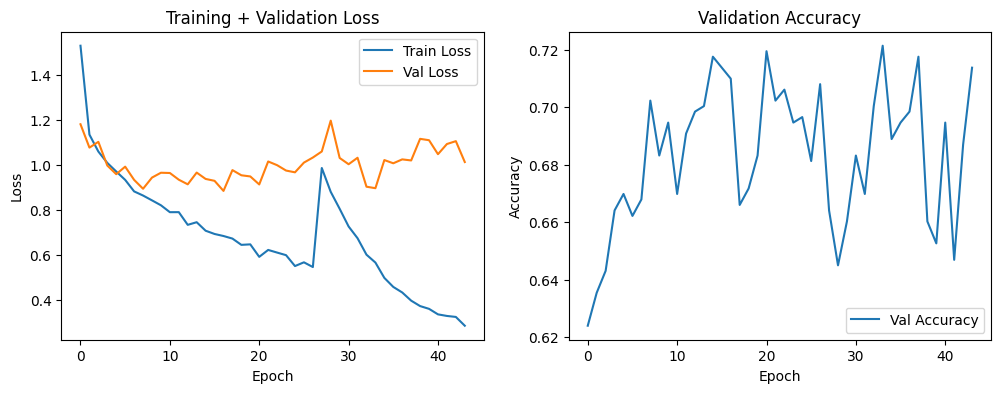

In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.00030995448268009645
best_lr_full = 5.816190742383745e-05
# Rebuild dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

wrapper_model = MutualCrossAttentionModel_3modalities(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

criterion = nn.CrossEntropyLoss()

# STAGE 1: HEAD ONLY
freeze_backbone_3_modalities(wrapper_model)


# Train only projections + attention + head
optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_3_modalities(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_images_metadata_1_best_stage1.pt"
)

# STAGE 2: Unfreeze everything
unfreeze_all_3_modalities(wrapper_model)

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_3_modalities(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_images_metadata_1_best_stage2.pt"
)

# --- End timer ---
end_time = time.time()

print(f"Total training time: {(end_time - start_time)/60:.2f} minutes")

# Plot
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

Total training time: 195.43 minutes

4.3 min per epoch

3.25h

### Run mutual cross attention a 2nd time

Using device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 180MB/s]


Epoch [1/1000] | Train Loss: 1.4115 | Val Loss: 1.1760 | Val Acc: 0.6240
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1087 | Val Loss: 1.0276 | Val Acc: 0.6641
Best model + history saved
Epoch [3/1000] | Train Loss: 1.0510 | Val Loss: 1.0673 | Val Acc: 0.6412
Epoch [4/1000] | Train Loss: 0.9862 | Val Loss: 0.9497 | Val Acc: 0.6756
Best model + history saved
Epoch [5/1000] | Train Loss: 0.9363 | Val Loss: 1.0018 | Val Acc: 0.6489
Epoch [6/1000] | Train Loss: 0.9160 | Val Loss: 0.9470 | Val Acc: 0.6775
Best model + history saved
Epoch [7/1000] | Train Loss: 0.8967 | Val Loss: 1.0081 | Val Acc: 0.6641
Epoch [8/1000] | Train Loss: 0.8657 | Val Loss: 0.9505 | Val Acc: 0.6947
Epoch [9/1000] | Train Loss: 0.8400 | Val Loss: 0.9004 | Val Acc: 0.6966
Best model + history saved
Epoch [10/1000] | Train Loss: 0.8111 | Val Loss: 0.9670 | Val Acc: 0.6908
Epoch [11/1000] | Train Loss: 0.8003 | Val Loss: 0.9369 | Val Acc: 0.6813
Epoch [12/1000] | Train Loss: 0.7694 | Val Loss: 0.9146 | Va

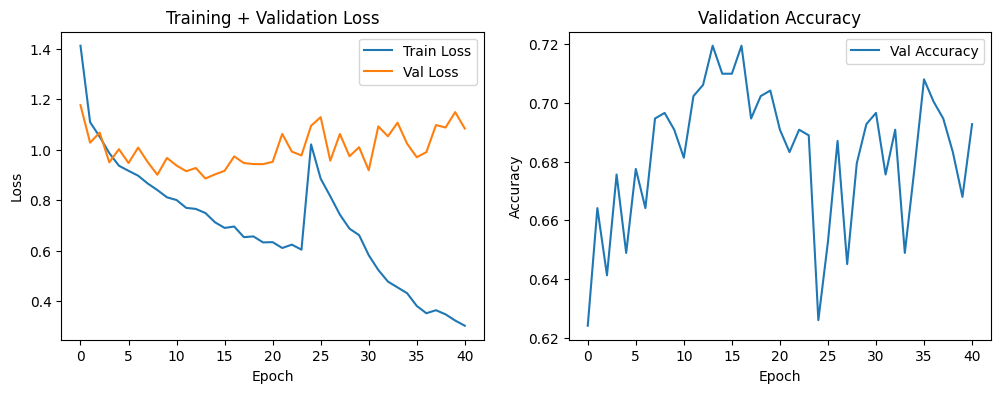

In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.00030995448268009645
best_lr_full = 5.816190742383745e-05
# Rebuild dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

wrapper_model = MutualCrossAttentionModel_3modalities(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

criterion = nn.CrossEntropyLoss()

# STAGE 1: HEAD ONLY
freeze_backbone_3_modalities(wrapper_model)


# Train only projections + attention + head
optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_3_modalities(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_images_metadata_1_best_run_2_stage1.pt"
)

# STAGE 2: Unfreeze everything
unfreeze_all_3_modalities(wrapper_model)

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_3_modalities(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_images_metadata_1_best_run_2_stage2.pt"
)

# --- End timer ---
end_time = time.time()

print(f"Total training time: {(end_time - start_time)/60:.2f} minutes")

# Plot
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

### Run mutual cross attention a 3rd time

Using device: cuda
Epoch [1/1000] | Train Loss: 1.5332 | Val Loss: 1.3044 | Val Acc: 0.6126
Best model + history saved
Epoch [2/1000] | Train Loss: 1.1469 | Val Loss: 1.0545 | Val Acc: 0.6622
Best model + history saved
Epoch [3/1000] | Train Loss: 1.0478 | Val Loss: 1.0808 | Val Acc: 0.6603
Epoch [4/1000] | Train Loss: 0.9996 | Val Loss: 0.9828 | Val Acc: 0.6775
Best model + history saved
Epoch [5/1000] | Train Loss: 0.9441 | Val Loss: 0.9769 | Val Acc: 0.6813
Best model + history saved
Epoch [6/1000] | Train Loss: 0.9120 | Val Loss: 0.9380 | Val Acc: 0.6851
Best model + history saved
Epoch [7/1000] | Train Loss: 0.8916 | Val Loss: 0.9714 | Val Acc: 0.6546
Epoch [8/1000] | Train Loss: 0.8644 | Val Loss: 0.9394 | Val Acc: 0.6813
Epoch [9/1000] | Train Loss: 0.8281 | Val Loss: 0.9393 | Val Acc: 0.6908
Epoch [10/1000] | Train Loss: 0.8237 | Val Loss: 0.9079 | Val Acc: 0.6794
Best model + history saved
Epoch [11/1000] | Train Loss: 0.7948 | Val Loss: 0.9099 | Val Acc: 0.6985
Epoch [12/1000

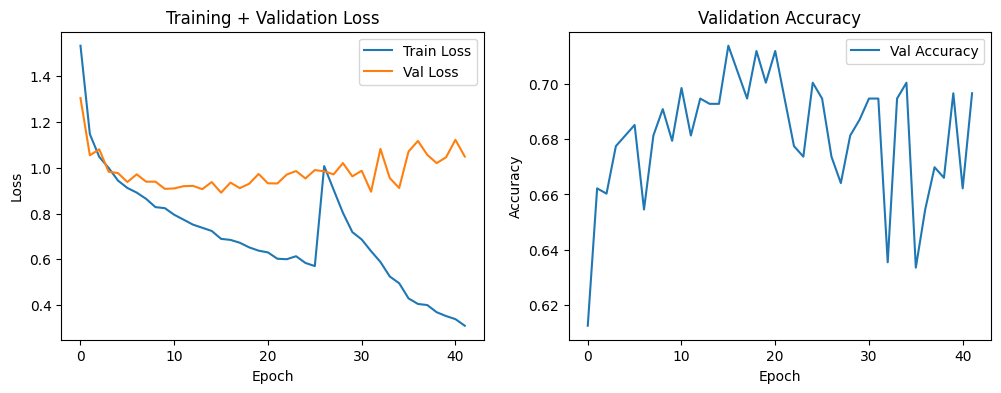

In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.00030995448268009645
best_lr_full = 5.816190742383745e-05
# Rebuild dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

wrapper_model = MutualCrossAttentionModel_3modalities(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

criterion = nn.CrossEntropyLoss()

# STAGE 1: HEAD ONLY
freeze_backbone_3_modalities(wrapper_model)


# Train only projections + attention + head
optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_3_modalities(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_images_metadata_1_best_run_3_stage1.pt"
)

# STAGE 2: Unfreeze everything
unfreeze_all_3_modalities(wrapper_model)

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_3_modalities(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_images_metadata_1_best_run_3_stage2.pt"
)

# --- End timer ---
end_time = time.time()

print(f"Total training time: {(end_time - start_time)/60:.2f} minutes")

# Plot
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

### Run 4 for debug of metadata usage in training.

In [ ]:
from VitClassifier_1_defnitions import *
import time
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
NUM_WORKERS = os.cpu_count()

# --- Start timer ---
start_time = time.time()

best_lr_head = 0.00030995448268009645
best_lr_full = 5.816190742383745e-05
# Rebuild dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

wrapper_model = MutualCrossAttentionModel_3modalities(
        metadata_dim=train_dataset.metadata_dim,
        num_classes=11
    ).to(device)

criterion = nn.CrossEntropyLoss()

# STAGE 1: HEAD ONLY
freeze_backbone_3_modalities(wrapper_model)


# Train only projections + attention + head
optimizer_stage1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, wrapper_model.parameters()),
    lr=best_lr_head
)

wrapper_model, history_stage1 = train_model_3_modalities(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage1,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_images_metadata_1_best_run_4_stage1.pt"
)

# STAGE 2: Unfreeze everything
unfreeze_all_3_modalities(wrapper_model)

optimizer_stage2 = torch.optim.AdamW(
    wrapper_model.parameters(),
    lr=best_lr_full
)

wrapper_model, history_stage2 = train_model_3_modalities(
    wrapper_model,
    train_loader,
    val_loader,
    criterion,
    optimizer_stage2,
    device,
    epochs=1000,
    patience=10,
    save_path=f"{CHECKPOINT_DIR}/Cross_images_metadata_1_best_run_4_stage2.pt"
)

# --- End timer ---
end_time = time.time()

print(f"Total training time: {(end_time - start_time)/60:.2f} minutes")

# Plot
import matplotlib.pyplot as plt

train_loss = history_stage1["train_loss"] + history_stage2["train_loss"]
val_loss   = history_stage1["val_loss"] + history_stage2["val_loss"]
val_acc    = history_stage1["val_acc"] + history_stage2["val_acc"]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training + Validation Loss")

plt.subplot(1,2,2)
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.show()

Using device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 188MB/s]


[Batch 0] Meta grad: 0.0000000000 | Image grad: 0.0040129549
full metadata vector:

tensor([0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500,
        0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.9000, 0.0500,
        0.0500, 0.9000, 0.0500, 0.0500, 0.0500, 0.9000, 0.0500, 0.0500, 0.0500,
        0.0500, 0.0500, 0.0500, 0.9000, 0.0500, 0.0500, 0.0500])
